***KHAI BÁO THƯ VIỆN VÀ TẢI DỮ LIỆU***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('spaceship-titanic/train.csv')
test_df = pd.read_csv('spaceship-titanic/test.csv')

print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

display(train_df.head())

Kích thước tập Train: (8693, 14)
Kích thước tập Test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


***EDA***

In [2]:
train_df.info()
print("\nMissing values:")
display(train_df.isnull().sum().sort_values(ascending=False))
display(train_df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB

Missing values:


CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
PassengerId       0
Transported       0
dtype: int64

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


- Ngoại trừ cột PassengerId và Transported thì tất cả các cột còn lại đều thiếu dữ liệu, nhưng số lượng thiếu chiếm tỉ lệ khá nhỏ so với tổng thể (khoảng 2% trên tổng số 8693 mẫu)
 + Đối với các biến phân loại: HomePlanet, Destination, VIP, CyroSleep, ta có thể sử dụng mode để điền khuyết.
 + Đối với các biến số: Chi tiêu dịch vụ, age, có thể sử dụng trung vị để điền khuyết. Đặc biệt, ta có thể suy luận rằng nếu hành khách có CyroSleep là True thì khả năng rất cao các khoản chi tiêu dịch vụ sẽ phải bằng 0.
  
- Đối với thống kê:
  + Các cột chi tiêu: RoomService, FoodCourt, ShoppingMall, Spa, VRDeck có giá trị median đều bằng 0, cho thấy phần lớn hành khách không chi trả nhiều cho các dịch vụ này. Nhưng có xuất hiện của các outliers và dữ liệu bị lệch phải rất nặng (max FoodCourt ~30000, ShoppingMall ~25000) => Có thể sử dụng Log transform để nén đuôi.
  + Cột Age phân bố khá hợp lý.

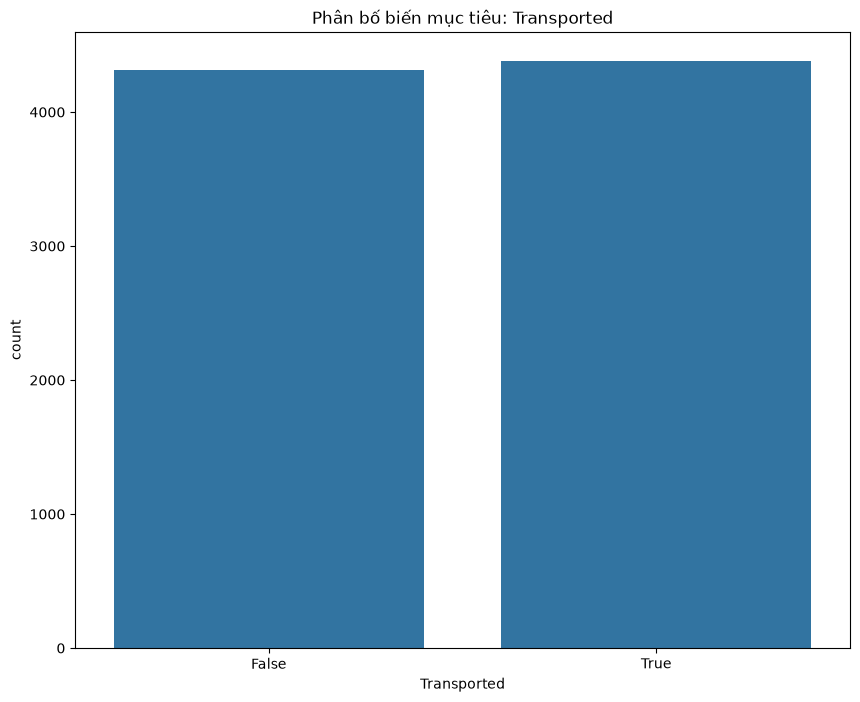

Tỷ lệ Transported:
Transported
True     50.362
False    49.638
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(10,8))
sns.countplot(data=train_df, x='Transported')
plt.title("Phân bố biến mục tiêu: Transported")
plt.show()
transported_percent = round(train_df['Transported'].value_counts(normalize=True) * 100, 3)
print(f"Tỷ lệ Transported:\n{transported_percent}")

Tỷ lệ Transported xấp xỉ 50-50, tập dữ liệu cân bằng lý tưởng.

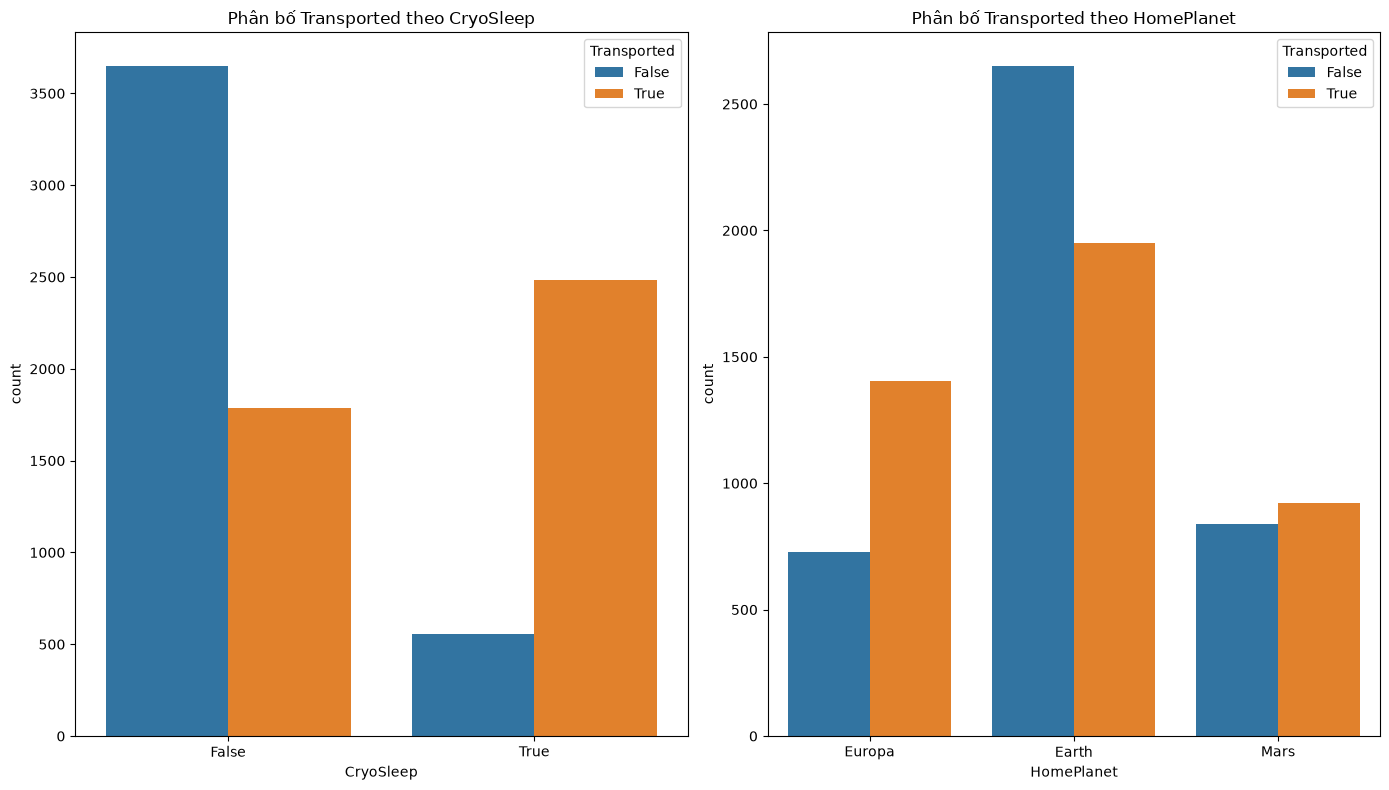

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.countplot(data=train_df, x='CryoSleep', hue='Transported', ax=axes[0])
axes[0].set_title('Phân bố Transported theo CryoSleep')

sns.countplot(data=train_df, x='HomePlanet', hue='Transported', ax=axes[1])
axes[1].set_title('Phân bố Transported theo HomePlanet')

plt.tight_layout()
plt.show()

- CryoSleep là đặc trưng mang tính phân loại tương đối mạnh. Với biểu đồ ở trên, ta có thể thấy rằng hành khách ở trạng thái ngủ đông (True) có khả năng được Transported lớn hơn rõ, và ngược lại, những người không ngủ đông thì có nguy cơ không được Transported cao hơn.
- HomePlanet cũng ảnh hưởng lớn đến việc phân loại. Tỷ lệ hành khách ở Europa được Transported cao hơn, ngược lại so với hành khách từ Earth và ở Mars thì khá cân bằng giữa hai bên.

***PREPROCESSING***

In [ ]:
from sklearn.model_selection import train_test_split

#Split val
y = train_df['Transported'].astype(int)
X = train_df.drop(columns=['Transported'])
kaggle_test = test_df.copy()

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=36
)

dfs = [X_train, X_val, kaggle_test]

#Tách feature Cabin
for df in dfs:
    df[['Cabin_deck', 'Cabin_num', 'Cabin_side']] = df['Cabin'].str.split('/', expand=True)
    df['Cabin_num'] = df['Cabin_num'].astype(float)
    #Drop các cột không dùng
    df.drop(columns=['PassengerId', 'Name', 'Cabin'], inplace=True)


num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_num']
cate_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_deck', 'Cabin_side']

fillna_values = {}

for col in num_cols:
    fillna_values[col] = X_train[col].median()

for col in cate_cols:
    fillna_values[col] = X_train[col].mode()[0]

#Điền khuyết dữ liệu cho cả 3 tập
for df in dfs:
    df.fillna(value=fillna_values, inplace=True)
    df['CryoSleep'] = df['CryoSleep'].astype(int)
    df['VIP'] = df['VIP'].astype(int)

#One-Hot Encoding, get-dummies và align
ohe_cols = ['HomePlanet', 'Destination', 'Cabin_deck', 'Cabin_side']

X_train = pd.get_dummies(X_train, columns=ohe_cols)
X_val = pd.get_dummies(X_val, columns=ohe_cols)
kaggle_test = pd.get_dummies(kaggle_test, columns=ohe_cols)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, kaggle_test = X_train.align(kaggle_test, join='left', axis=1, fill_value=0)

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_val: {X_val.shape}")
print(f"Kích thước kaggle_test: {kaggle_test.shape}")

Kích thước X_train: (6954, 25)
Kích thước X_val: (1739, 25)
Kích thước kaggle_test: (4277, 25)



 - Dữ liệu được chia thành 80% Train và 20% Validation. 
 - Cột Cabin được tách thành 3 cột riêng biệt là Cabin_deck, Cabin_num, và Cabin_side nhằm giữ lại thông tin về vị trí không gian của hành khách, nếu để nguyên thì mô hình sẽ xem mỗi phòng là một mẫu dữ liệu riêng, dễ khiến mô hình bị overfitting. Drop các cột định danh không có giá trị dự đoán như PassengerId, Name.
- Điền khuyết dữ liệu:
   + Biến số: Điền bằng median.
   + Biến phân loại: Điền bằng giá trị mode.

**BAGGING**

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier(
    n_estimators=167,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=67,
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_pred)

**Boosting**

In [7]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=167,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=6767,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_pred)

**Stacking**

In [8]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators = [
    ("rf", rf),
    ("xgb", xgb)
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000)
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_val)
stack_acc = accuracy_score(y_val, stack_pred)

**Benchmark**

In [9]:
results = {
    'Model': ['Random Forest', 'XGBoost', 'Stacking'],
    'Accuracy': [rf_acc, xgb_acc, stack_acc]
}

benchmark_df = pd.DataFrame(results).sort_values(by='Accuracy')
display(benchmark_df)

,Model,Accuracy
0,Random Forest,0.808511
1,XGBoost,0.811961
2,Stacking,0.813686


Stacking có accuracy cao nhất trong 3 mô hình.

**Submission**

In [10]:
final_predictions = stack.predict(kaggle_test).astype(bool)
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Transported': final_predictions
})

submission.to_csv('submission.csv', index=False)
print("Đã xuất file submission.csv thành công!")

display(submission.head())

Đã xuất file submission.csv thành công!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


Score đạt được trên submission của Kaggle: 0.80266